# Variable Glossary
- definition
- correlation
- scatterplot

In [1]:
import pandas as pd
import numpy as np
from pandas import read_csv
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
filename = "celiac_disease_lab_data.csv"
df = pd.read_csv(filename)
df.head()

,Age,Gender,Diabetes,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,Male,Yes,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,marsh type 0,potential,yes
1,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,marsh type 3a,atypical,yes
2,8,Female,Yes,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,marsh type 1,latent,yes
3,10,Male,Yes,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,marsh type 3a,silent,yes
4,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,marsh type 1,latent,yes


In [3]:
df.dtypes

Age                   int64
Gender               object
Diabetes             object
Diabetes_Type        object
Diarrhea             object
Abdominal            object
Short_Stature        object
Sticky_Stool         object
Weight_loss          object
IgA                 float64
IgG                 float64
IgM                 float64
Marsh                object
cd_type              object
Disease_Diagnose     object
dtype: object

In [4]:
df["Diabetes_Type"] = df["Diabetes_Type"].fillna(0)

In [6]:
df.isna().sum()

Age                 0
Gender              0
Diabetes            0
Diabetes_Type       0
Diarrhea            0
Abdominal           0
Short_Stature       0
Sticky_Stool        0
Weight_loss         0
IgA                 0
IgG                 0
IgM                 0
Marsh               0
cd_type             0
Disease_Diagnose    0
dtype: int64

In [7]:
df_num = df.select_dtypes(include=[np.number])
df_cat = df.select_dtypes(include=['object'])

Visualizing Correlations Between Variables: 
- using a correlation matrix for numeric variables
- using Cramer's V to measure correlation between categorical variables (derived from chi-square)
- using correlation ratio for correlation between categorical and numeric variables (how much of the numeric variation can be explained by the categorical variable's groups)

In [8]:
# starting with age
df['Age'].describe()

count    2206.000000
mean       12.768812
std         7.434250
min         1.000000
25%         8.000000
50%        10.000000
75%        15.000000
max        35.000000
Name: Age, dtype: float64

In [9]:
df['IgA'].describe()

count    2206.000000
mean        1.427384
std         1.110042
min         0.340000
25%         1.000000
50%         1.100000
75%         1.800000
max         9.000000
Name: IgA, dtype: float64

In [10]:
df['IgG'].describe()

count    2206.000000
mean       10.052901
std         2.047683
min         5.000000
25%         8.700000
50%        10.000000
75%        12.000000
max        15.300000
Name: IgG, dtype: float64

In [11]:
df['IgM'].describe()

count    2206.000000
mean        1.236963
std         0.447216
min         0.500000
25%         0.980000
50%         1.100000
75%         1.500000
max         2.700000
Name: IgM, dtype: float64

In [12]:
df['Marsh'].describe()

count              2206
unique                7
top       marsh type 3b
freq                445
Name: Marsh, dtype: object

<Axes: >

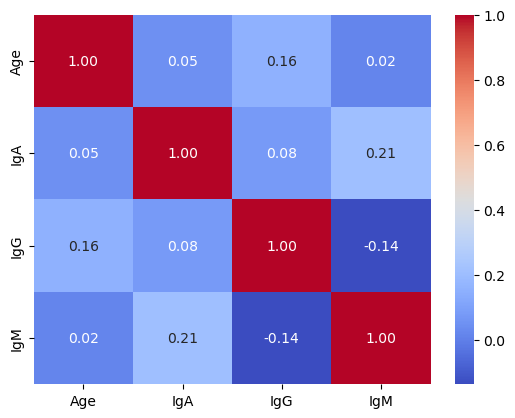

In [13]:
# correlation matrix for numeric variables
correlation_matrix = df_num.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')

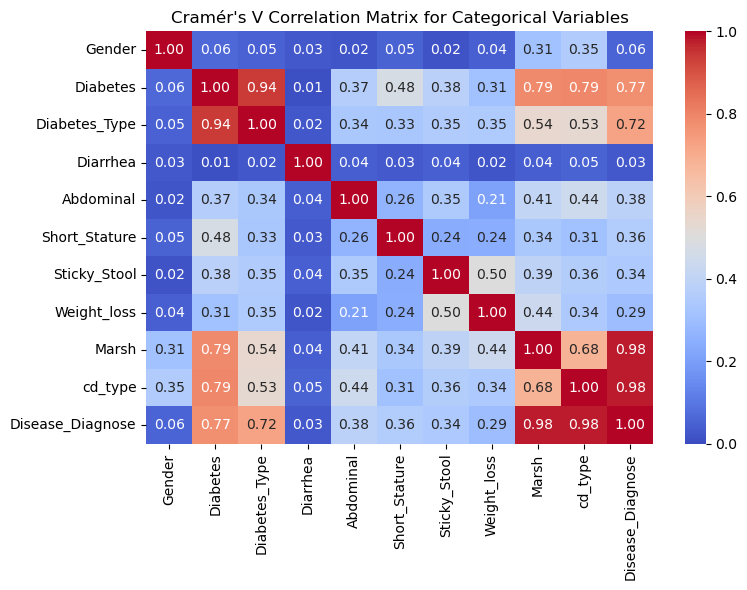

In [14]:
# cramer's v for categorical variables
cramers_matrix = pd.DataFrame(
    np.zeros((len(df_cat.columns), len(df_cat.columns))),
    columns=df_cat.columns,
    index=df_cat.columns
)

for col1 in df_cat.columns:
    for col2 in df_cat.columns:
        contingency_table = pd.crosstab(df_cat[col1], df_cat[col2])
        chi2 = chi2_contingency(contingency_table)[0]
        n = contingency_table.sum().sum()
        phi2 = chi2 / n
        r, k = contingency_table.shape
        phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
        rcorr = r - ((r - 1) ** 2) / (n - 1)
        kcorr = k - ((k - 1) ** 2) / (n - 1)
        cramers_matrix.loc[col1, col2] = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

plt.figure(figsize=(8,6))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=0) 
plt.title("Cramér's V Correlation Matrix for Categorical Variables")
plt.tight_layout()
plt.show()


Mixed results here - definitely reinforces that I have to drop marsh and cd_type. marsh almost is disease_diagnose, which makes sense. same with diabetes and diabetes_type. Think I can drop diabetes. Interesting that gender has a much higher correlation with marsh and cd_type than it does with disease_diagnose. Not exactly sure what that means.

In [17]:
df_num.isnull().sum()

Age    0
IgA    0
IgG    0
IgM    0
dtype: int64

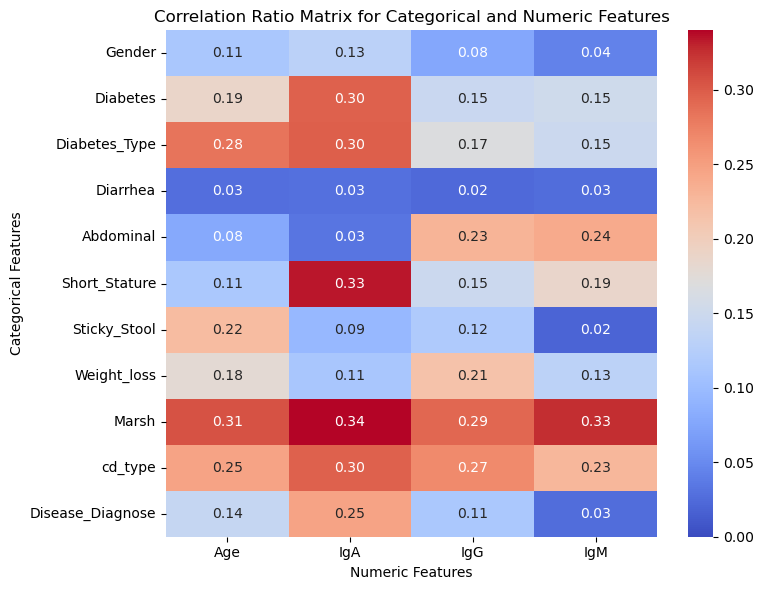

In [19]:
# correlation ratio
mix_matrix = pd.DataFrame(
    np.zeros((len(df_cat.columns), len(df_num.columns))), 
    columns = df_num.columns,
    index = df_cat.columns
)
for cat_col in df_cat.columns:
    for num_col in df_num.columns:
        categories = np.array(df_cat[cat_col].astype(str))
        values = np.array(df_num[num_col])

        # handle nan values
        mask = ~np.isnan(values) | pd.isna(values)
        categories = categories[mask]
        values = values[mask]

        overall_mean = np.mean(values)
        ssw = 0

        for category in np.unique(categories):
            group = values[categories == category]
            ssw += np.sum((group - np.mean(group)) ** 2)

        sst = np.sum((values - overall_mean) ** 2)

        if sst == 0:
            mix_matrix.loc[cat_col, num_col] = 0.0
        else:
            mix_matrix.loc[cat_col, num_col] = np.sqrt(1 - (ssw / sst))

plt.figure(figsize=(8, 6))
sns.heatmap(mix_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=0)
plt.title("Correlation Ratio Matrix for Categorical and Numeric Features")
plt.xlabel("Numeric Features")
plt.ylabel("Categorical Features")
plt.tight_layout() 
plt.show()

No super high correlations - means there is no categorical variable perfectly explained by a numeric one. This is good, and it also tells us to look more into the pairings with a higher correlation.